Imagine that you are a medical researcher compiling data for a study. You have collected data about a set of patients, all of whom suffered from the same illness. During their course of treatment, each patient responded to one of 5 medications, Drug A, Drug B, Drug c, Drug x and y.
Part of your job is to build a model to find out which drug might be appropriate for a future patient with the same illness. The features of this dataset are Age, Sex, Blood Pressure, and the Cholesterol of the patients, and the target is the drug that each patient responded to.
It is a sample of multiclass classifier, and you can use the training part of the dataset to build a decision tree, and then use it to predict the class of a unknown patient, or to prescribe a drug to a new patient.

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [45]:
df=pd.read_csv("drug.csv")

In [46]:
df

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [48]:
for i in df:
  print(i,":",df[i].unique())
  print("********************************")

Age : [23 47 28 61 22 49 41 60 43 34 74 50 16 69 32 57 63 48 33 31 39 45 18 65
 53 46 15 73 58 66 37 68 67 62 24 26 40 38 29 17 54 70 36 19 64 59 51 42
 56 20 72 35 52 55 30 21 25]
********************************
Sex : ['F' 'M']
********************************
BP : ['HIGH' 'LOW' 'NORMAL']
********************************
Cholesterol : ['HIGH' 'NORMAL']
********************************
Na_to_K : [25.355 13.093 10.114  7.798 18.043  8.607 16.275 11.037 15.171 19.368
 11.767 19.199 15.376 20.942 12.703 15.516 11.455 13.972  7.298 25.974
 19.128 25.917 30.568 15.036 33.486 18.809 30.366  9.381 22.697 17.951
  8.75   9.567 11.014 31.876 14.133  7.285  9.445 13.938  9.709  9.084
 19.221 14.239 15.79  12.26  12.295  8.107 13.091 10.291 31.686 19.796
 19.416 10.898 27.183 18.457 10.189 14.16  11.34  27.826 10.091 18.703
 29.875  9.475 20.693  8.37  13.303 27.05  12.856 10.832 24.658 24.276
 13.967 19.675 10.605 22.905 17.069 20.909 11.198 19.161 13.313 10.84
 13.934  7.761  9.712 11.326 10.0

ANALYSIS

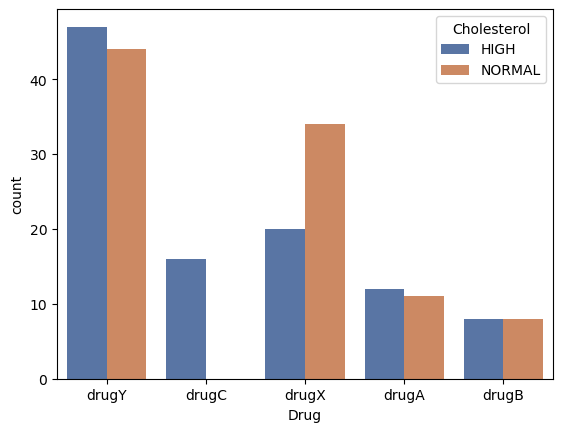

In [49]:
sns.countplot(x="Drug",data=df,hue="Cholesterol",palette="deep")
plt.show()

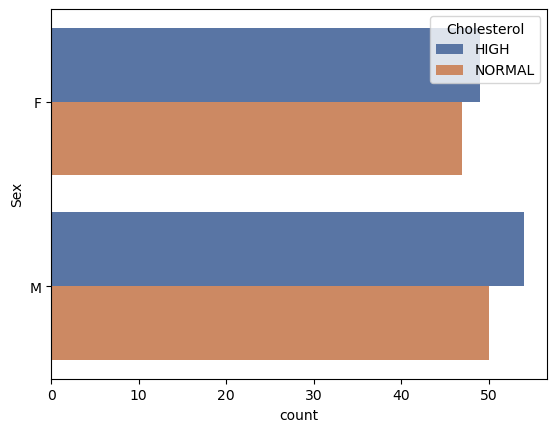

In [50]:
sns.countplot(y="Sex",data=df,hue="Cholesterol",palette="deep")
plt.show()

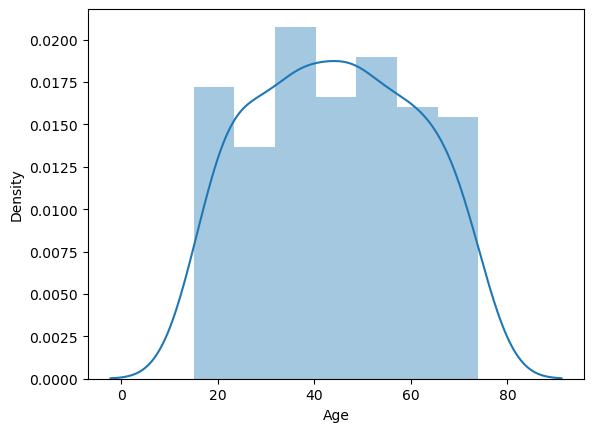

In [51]:
sns.distplot(df["Age"])
plt.show()

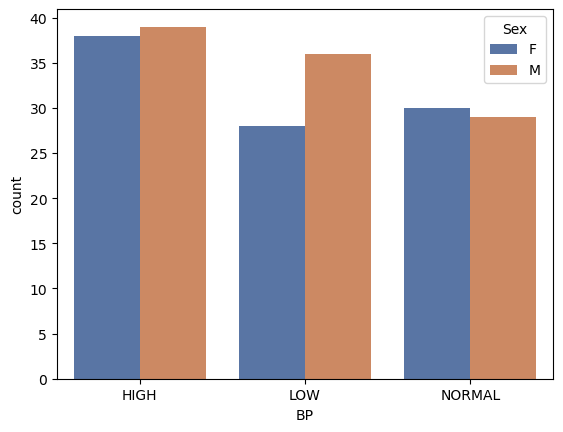

In [52]:
sns.countplot(x="BP",data=df,hue="Sex",palette="deep")
plt.show()

In [53]:
from sklearn.preprocessing import LabelEncoder


In [54]:
le_sex=LabelEncoder()
le_BP=LabelEncoder()
le_chol=LabelEncoder()
le_drug=LabelEncoder()

In [55]:
df["Sex"]=le_sex.fit_transform(df["Sex"])
df["BP"]=le_BP.fit_transform(df["BP"])
df["Cholesterol"]=le_chol.fit_transform(df["Cholesterol"])
df["Drug"]=le_drug.fit_transform(df["Drug"])

In [56]:
df

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,0,0,25.355,4
1,47,1,1,0,13.093,2
2,47,1,1,0,10.114,2
3,28,0,2,0,7.798,3
4,61,0,1,0,18.043,4
...,...,...,...,...,...,...
195,56,0,1,0,11.567,2
196,16,1,1,0,12.006,2
197,52,1,2,0,9.894,3
198,23,1,2,1,14.020,3


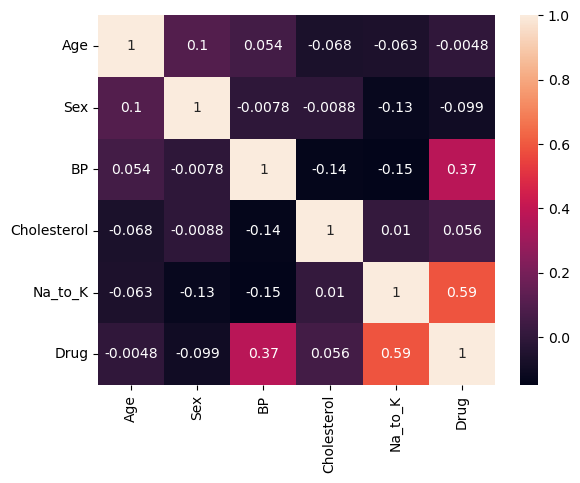

In [57]:
sns.heatmap(df.corr(),annot=True)
plt.show()

In [58]:
X=df.drop("Drug",axis=1)
Y=df["Drug"]

In [59]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.3,random_state=1)

In [60]:

from sklearn.tree import DecisionTreeClassifier


In [61]:
dt=DecisionTreeClassifier()


In [62]:
dt.fit(X_train,Y_train)

DecisionTreeClassifier()

In [63]:
print("TRAINING SCORE")
print("DT SCORE",dt.score(X_train,Y_train))


TRAINING SCORE
DT SCORE 1.0


In [64]:
print("TESTING SCORE")
print("DT SCORE",dt.score(X_test,Y_test))


TESTING SCORE
DT SCORE 0.9666666666666667


In [65]:
y_pred=dt.predict(X_train)

In [66]:
y_predtest=dt.predict(X_test)

In [67]:
from sklearn.metrics import confusion_matrix,classification_report

In [68]:
print(classification_report(Y_test,y_predtest))

              precision    recall  f1-score   support

           0       0.67      1.00      0.80         4
           1       1.00      0.67      0.80         6
           2       1.00      1.00      1.00         4
           3       1.00      1.00      1.00        19
           4       1.00      1.00      1.00        27

    accuracy                           0.97        60
   macro avg       0.93      0.93      0.92        60
weighted avg       0.98      0.97      0.97        60



In [69]:
import pickle

In [70]:
#Save model
pickle.dump(dt,open("dtmodel.pkl","wb"))

In [72]:
#Save encoder model

pickle.dump((le_sex,le_BP,le_chol,le_drug),open("encoders.pkl","wb"))

print("Model saved successfully")

Model saved successfully
